In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Problem 2: A visual history of Nobel prize winners

In [65]:
# load the data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/nobel.csv'
nobel = pd.read_csv(url)

Display the first 10 rows.

In [3]:
nobel.head(10)

,Year,Category,Prize,Motivation,Prize Share,Laureate ID,Laureate Type,Full Name,Birth Date,Birth City,Birth Country,Sex,Organization Name,Organization City,Organization Country,Death Date,Death City,Death Country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France
5,1901,Physics,The Nobel Prize in Physics 1901,"""in recognition of the extraordinary services ...",1/1,1,Individual,Wilhelm Conrad Röntgen,1845-03-27,Lennep (Remscheid),Prussia (Germany),Male,Munich University,Munich,Germany,1923-02-10,Munich,Germany
6,1902,Chemistry,The Nobel Prize in Chemistry 1902,"""in recognition of the extraordinary services ...",1/1,161,Individual,Hermann Emil Fischer,1852-10-09,Euskirchen,Prussia (Germany),Male,Berlin University,Berlin,Germany,1919-07-15,Berlin,Germany
7,1902,Literature,The Nobel Prize in Literature 1902,"""the greatest living master of the art of hist...",1/1,571,Individual,Christian Matthias Theodor Mommsen,1817-11-30,Garding,Schleswig (Germany),Male,NaN,NaN,NaN,1903-11-01,Charlottenburg,Germany
8,1902,Medicine,The Nobel Prize in Physiology or Medicine 1902,"""for his work on malaria, by which he has show...",1/1,294,Individual,Ronald Ross,1857-05-13,Almora,India,Male,University College,Liverpool,United Kingdom,1932-09-16,Putney Heath,United Kingdom
9,1902,Peace,The Nobel Peace Prize 1902,NaN,1/2,464,Individual,Élie Ducommun,1833-02-19,Geneva,Switzerland,Male,NaN,NaN,NaN,1906-12-07,Bern,Switzerland


## Part 1: who gets the Nobel Prize?

Count the number of rows (prizes) 

In [4]:
len(nobel)

969

Count the number of prizes, grouped by `sex`.

In [7]:
nobel.groupby('Sex').Prize.count() # this counts the number of prizes
# note that the sum is different than the number of rows because some rows are not 'full' prizes !

Sex
Female     50
Male      893
Name: Prize, dtype: int64

Count the number of prizes, grouped by `Birth Country`. Arrange the result by no. prizes in descending order and display the first 20 rows.

In [13]:
nobel.groupby('Birth Country').Prize.count().sort_values(ascending=False).head(20)

Birth Country
United States of America    276
United Kingdom               88
Germany                      70
France                       53
Sweden                       30
Japan                        29
Russia                       20
Netherlands                  19
Canada                       18
Italy                        18
Switzerland                  17
Austria                      15
Norway                       13
China                        12
Australia                    11
Denmark                      11
Germany (Poland)             10
Scotland                      9
Belgium                       9
South Africa                  9
Name: Prize, dtype: int64

## Part 2: USA dominance

Add a `usa_born_winner` column to the `nobel` DataFrame, where the value is `TRUE` when `Birth Country` is "United States of America".

In [14]:
nobel['usa_born_winner'] = nobel['Birth Country'] == "United States of America"

Add a `decade` column to the `nobel` DataFrame showing the decade the prize was awarded (1953 should become 1950, for example).

In [1]:
# Hint: you can use Python floor division // to compute the decade of a year
(1953//10)*10

1950

In [16]:
nobel['decade'] = (nobel.Year//10)*10

Calculate the percentage of USA born winners for each decade.

In [20]:
win_percent = 100*nobel.groupby('decade').usa_born_winner.mean()

win_percent

decade
1900     1.724138
1910     7.500000
1920     7.407407
1930    24.193548
1940    28.888889
1950    27.848101
1960    26.250000
1970    30.841121
1980    31.313131
1990    39.252336
2000    41.428571
2010    33.673469
Name: usa_born_winner, dtype: float64

Plot the percentage of USA born winners per decade.

<AxesSubplot:xlabel='decade'>

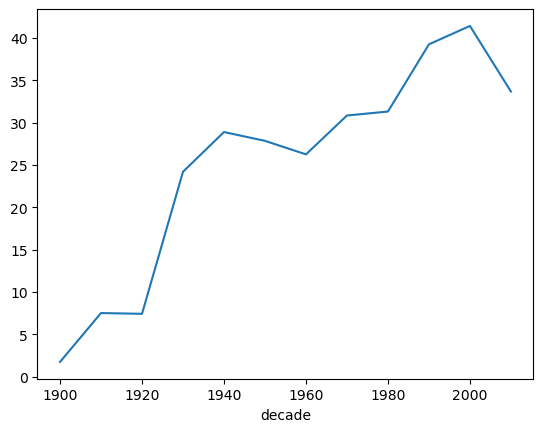

In [21]:
win_percent.plot()

## Part 3: What is the gender of a typical Nobel Prize winner?

Add a `female_winner` column, where the value is `TRUE` when `Sex` is 'Female'

In [22]:
nobel['female_winner'] = nobel['Sex'] == 'Female'

Calculate the percentage of female winners by decade and category.

In [28]:
table = pd.pivot_table(data=nobel, values='female_winner', index='decade', columns='Category', aggfunc='mean').fillna(0)
table

Category,Chemistry,Economics,Literature,Medicine,Peace,Physics
decade,,,,,,
1900,0.000000,0.000000,0.100000,0.000000,0.071429,0.076923
1910,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000
1920,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000
1930,0.055556,0.000000,0.111111,0.000000,0.111111,0.000000
1940,0.000000,0.000000,0.166667,0.066667,0.142857,0.000000
1950,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1960,0.066667,0.000000,0.090909,0.000000,0.000000,0.055556
1970,0.000000,0.000000,0.000000,0.038462,0.230769,0.000000
1980,0.000000,0.000000,0.000000,0.130435,0.090909,0.000000


Plot the percentage of female winners by decade and category.

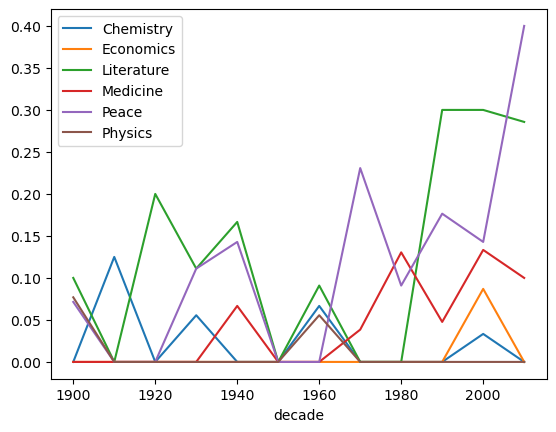

In [32]:
for col in table.columns:
    table[col].plot(label=col, legend=True)


## Part 4: The first woman to win the Nobel Prize

Find the first woman to win a Nobel Prize.

In [35]:
nobel[nobel.female_winner == True].head(1)['Full Name'] # the dataframe is sorted by year

19    Marie Curie, née Sklodowska
Name: Full Name, dtype: object

## Part 5: Repeat laureates

Use the `count` method to count the number of wins grouped by `Full Name`.

In [39]:
nobel.groupby('Full Name').Prize.count()

Full Name
A. Michael Spence    1
Aage Niels Bohr      1
Aaron Ciechanover    1
Aaron Klug           1
Abdus Salam          2
                    ..
Youyou Tu            1
Yuan T. Lee          1
Yves Chauvin         1
Zhores I. Alferov    1
Élie Ducommun        1
Name: Prize, Length: 904, dtype: int64

## Part 6: How old are you when you get the prize?

Fix Albert John Lutuli and A. Michael Spence `Birth Date` values

In [67]:
nobel.loc[nobel['Full Name']== 'A. Michael Spence'] # born on november 7th

,Year,Category,Prize,Motivation,Prize Share,Laureate ID,Laureate Type,Full Name,Birth Date,Birth City,Birth Country,Sex,Organization Name,Organization City,Organization Country,Death Date,Death City,Death Country
748,2001,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for their analyses of markets with asymmetric...",1/3,745,Individual,A. Michael Spence,1943-00-00,"Montclair, NJ",United States of America,Male,Stanford University,"Stanford, CA",United States of America,NaN,NaN,NaN


In [46]:
nobel.loc[nobel['Full Name']== 'Albert John Lutuli'] # has known birth year but not birth date

,Year,Category,Prize,Motivation,Prize Share,Laureate ID,Laureate Type,Full Name,Birth Date,Birth City,...,Sex,Organization Name,Organization City,Organization Country,Death Date,Death City,Death Country,usa_born_winner,decade,female_winner
342,1960,Peace,The Nobel Peace Prize 1960,NaN,1/1,519,Individual,Albert John Lutuli,1898-00-00,Bulawayo,...,Male,NaN,NaN,NaN,1967-07-21,Stanger,South Africa,False,1960,False


In [68]:
nobel.at[748,'Birth Date'] = '1943-07-12'

In [72]:
nobel.at[342,'Birth Date'] = '1898-01-01' # just picking the first day of the year, wikipedia was no helo

In [73]:
nobel['Birth Date'] = pd.to_datetime(nobel['Birth Date'])

In [74]:
nobel.loc[nobel['Full Name']== 'Albert John Lutuli']

,Year,Category,Prize,Motivation,Prize Share,Laureate ID,Laureate Type,Full Name,Birth Date,Birth City,Birth Country,Sex,Organization Name,Organization City,Organization Country,Death Date,Death City,Death Country
342,1960,Peace,The Nobel Peace Prize 1960,NaN,1/1,519,Individual,Albert John Lutuli,1898-01-01,Bulawayo,Southern Rhodesia (Zimbabwe),Male,NaN,NaN,NaN,1967-07-21,Stanger,South Africa


Calculate how old people were when they got their prize. Assign the resulting Series to the `nobel_age` column.

In [80]:
nobel['nobel_age'] = nobel['Year'] - nobel['Birth Date'].dt.year

Plot `nobel_age` as a function of `Year` as a scatter plot.

<AxesSubplot:xlabel='Year', ylabel='nobel_age'>

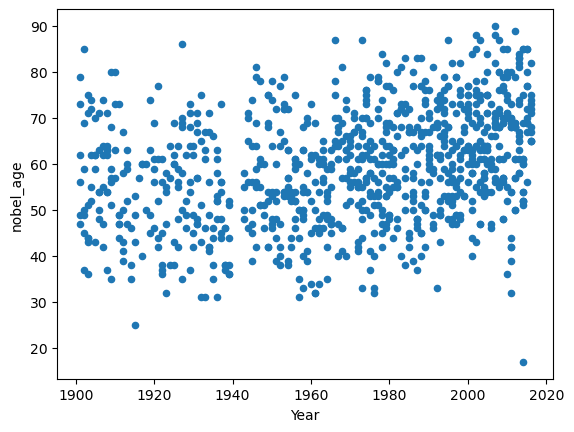

In [81]:
nobel.plot.scatter('Year', 'nobel_age')

## Part 6: Oldest and youngest winners

Find the oldest winner.

In [82]:
nobel[nobel.nobel_age == nobel.nobel_age.max()]

,Year,Category,Prize,Motivation,Prize Share,Laureate ID,Laureate Type,Full Name,Birth Date,Birth City,Birth Country,Sex,Organization Name,Organization City,Organization Country,Death Date,Death City,Death Country,nobel_age
825,2007,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having laid the foundations of mechanism ...",1/3,820,Individual,Leonid Hurwicz,1917-08-21,Moscow,Russia,Male,University of Minnesota,"Minneapolis, MN",United States of America,2008-06-24,"Minneapolis, MN",United States of America,90.0


Find the youngest winner.

In [83]:
nobel[nobel.nobel_age == nobel.nobel_age.min()]

,Year,Category,Prize,Motivation,Prize Share,Laureate ID,Laureate Type,Full Name,Birth Date,Birth City,Birth Country,Sex,Organization Name,Organization City,Organization Country,Death Date,Death City,Death Country,nobel_age
940,2014,Peace,The Nobel Peace Prize 2014,"""for their struggle against the suppression of...",1/2,914,Individual,Malala Yousafzai,1997-07-12,Mingora,Pakistan,Female,NaN,NaN,NaN,NaN,NaN,NaN,17.0
